## 1. Data Exploration & Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_raw = pd.read_csv('data/arxiv_clean.csv')
print(f"Shape: {df_raw.shape}")
print(df_raw['category'].value_counts())
df_raw.head(5)

Shape: (9013, 3)
category
cs.RO    1916
cs.LG    1891
cs.DB    1790
cs.CR    1765
cs.PL    1651
Name: count, dtype: int64


,abstract,text,category
0,Model-based offline Reinforcement Learning (RL...,model base offline reinforcement learn rl allo...,cs.LG
1,Mental disorders such as Autism Spectrum Disor...,mental disorder such a autism spectrum disorde...,cs.LG
2,Re-scale boosting (RBoosting) is a variant of ...,re scale boost rboosting be a variant of boost...,cs.LG
3,We introduce a Graph Transformer framework tha...,we introduce a graph transformer framework tha...,cs.LG
4,Patient flow analysis can be studied from a cl...,patient flow analysis can be study from a clin...,cs.LG


In [2]:
print('Missing values:')
missing = df_raw.isnull().sum()
if missing.any():
    print(missing[missing > 0])
else:
    print('No missing values')

Missing values:
No missing values


TF-IDF: (9013, 5000)
Top 20 tokens overall: ['framework' 'language' 'provide' 'present' 'program' 'task' 'problem'
 'performance' 'time' 'learn' 'result' 'algorithm' 'paper' 'approach'
 'method' 'propose' 'base' 'use' 'model' 'data']


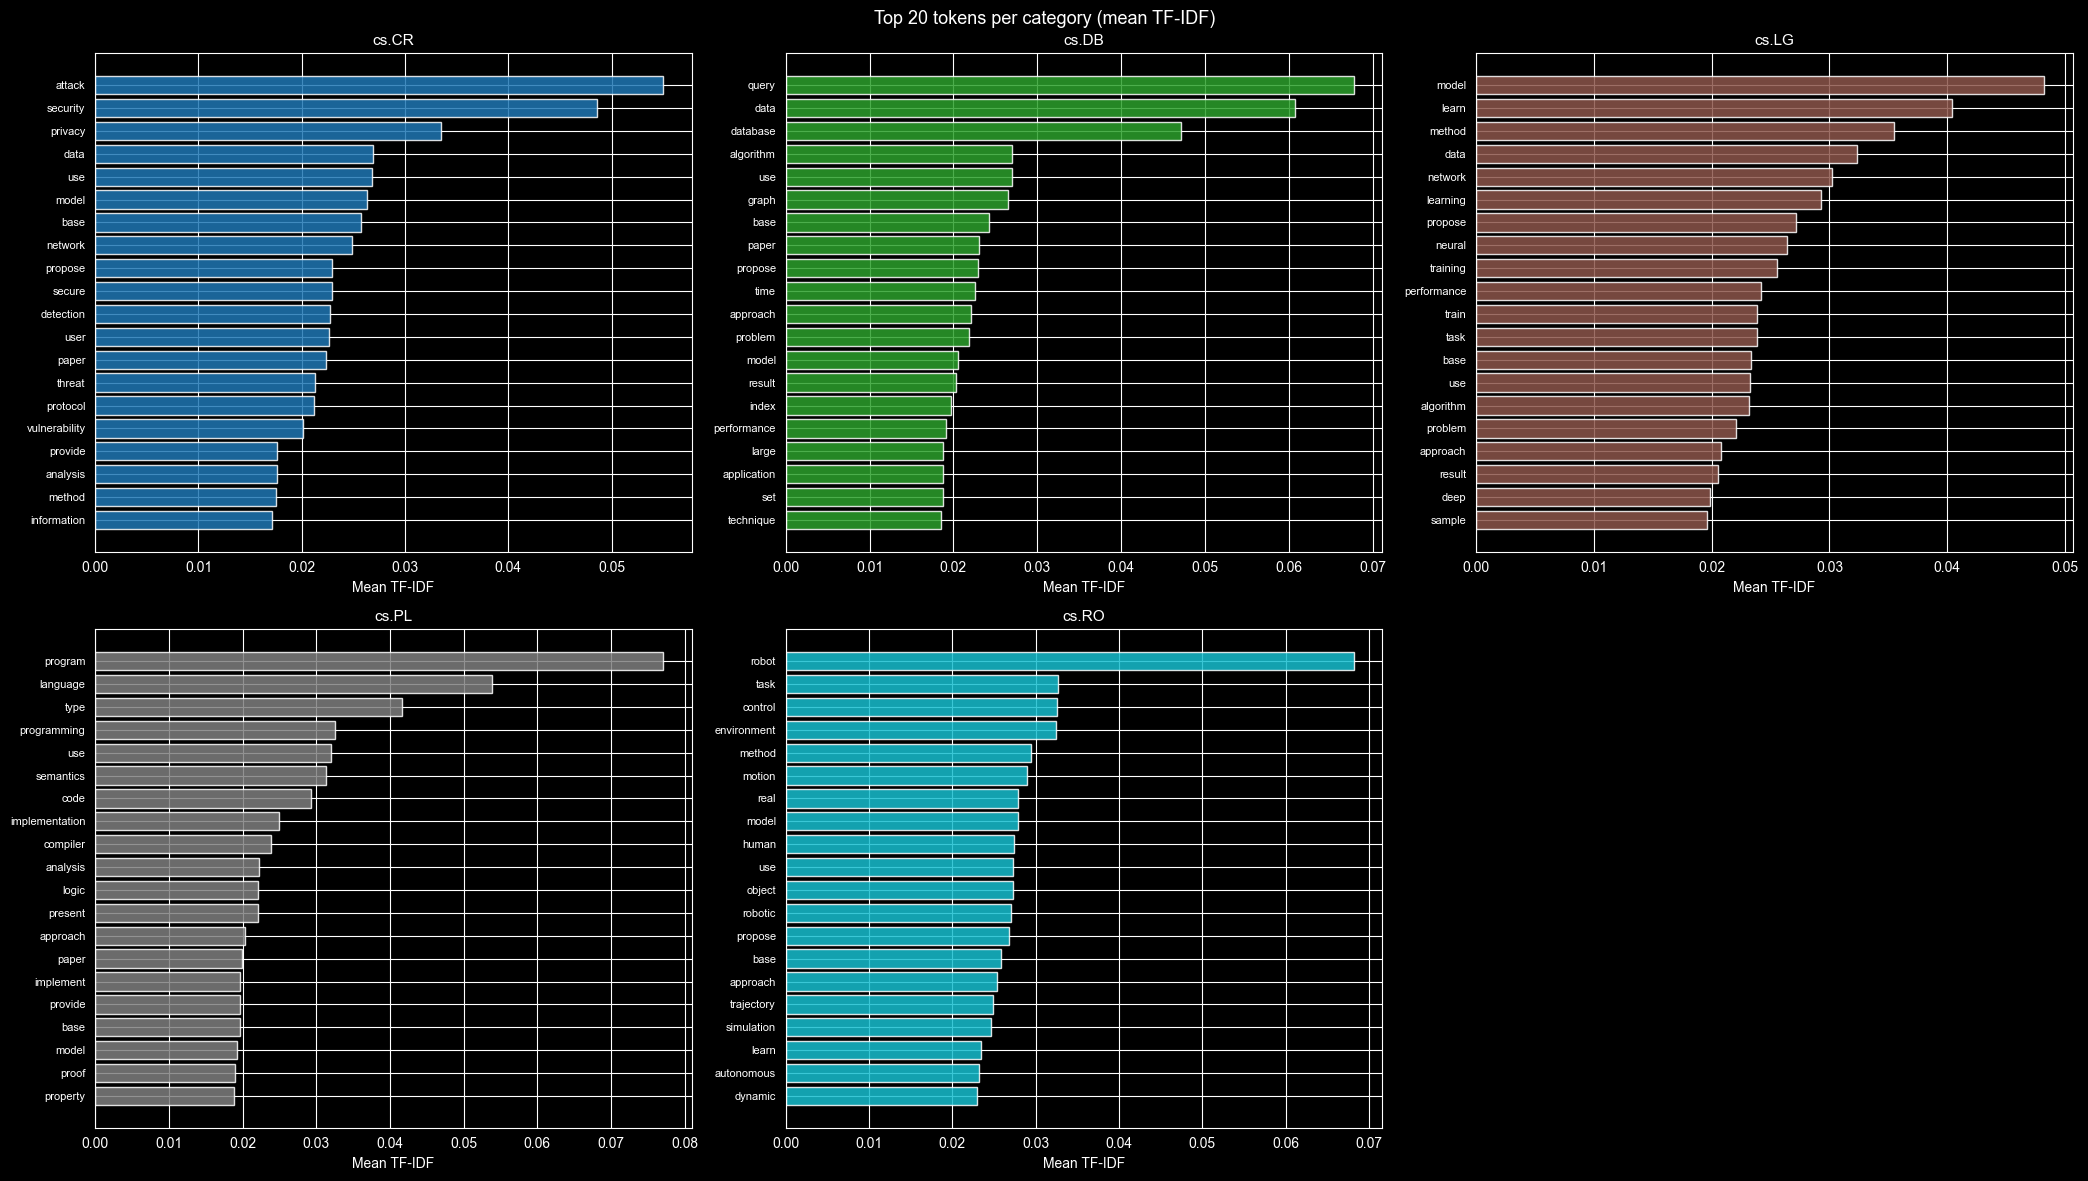

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
import math

tfidf = TfidfVectorizer(max_features=5000, stop_words='english',
                        min_df=5, sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df_raw['text'])
print(f'TF-IDF: {X_tfidf.shape}')

vocab = np.array(tfidf.get_feature_names_out())
TOP_N = 20

total_scores = np.asarray(X_tfidf.sum(axis=0)).ravel()
top_idx      = total_scores.argsort()[-TOP_N:][::-1]
print(f'Top {TOP_N} tokens overall: {vocab[top_idx][::-1]}')

sorted_cats = sorted(df_raw['category'].unique())
cmap5  = plt.get_cmap('tab10', len(sorted_cats))
colors = {cat: cmap5(i) for i, cat in enumerate(sorted_cats)}

NCOLS = 3
NROWS = math.ceil(len(sorted_cats) / NCOLS)

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 7, NROWS * 6))
axes = axes.flatten()

for ax, cat in zip(axes, sorted_cats):
    mask       = (df_raw['category'] == cat).values
    cat_scores = np.asarray(X_tfidf[mask].mean(axis=0)).ravel()
    top_idx    = cat_scores.argsort()[-TOP_N:][::-1]
    ax.barh(vocab[top_idx][::-1], cat_scores[top_idx][::-1],
            color=colors[cat], alpha=0.85)
    ax.set_title(cat, fontsize=11)
    ax.set_xlabel('Mean TF-IDF')
    ax.tick_params(axis='y', labelsize=8)

for ax in axes[len(sorted_cats):]:
    ax.set_visible(False)

plt.suptitle(f'Top {TOP_N} tokens per category (mean TF-IDF)', fontsize=13)
plt.tight_layout(); plt.show()

In [4]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
X_emb = model.encode(
    df_raw['abstract'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
)
print(f'Embeddings: {X_emb.shape}')

dataset = pd.DataFrame(X_emb, columns=[f'emb_{i}' for i in range(X_emb.shape[1])])
dataset['category'] = df_raw['category'].values

/Users/vika/PycharmProjects/DataMining/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/vika/PycharmProjects/DataMining/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 141/141 [00:26<00:00,  5.29it/s]

Embeddings: (9013, 384)


## 2. Association Rules

In [5]:
from mlxtend.frequent_patterns import apriori, fpgrowth

TOP_TOKENS        = 256
MIN_DOC_FREQ_LOW  = 0.05
MIN_DOC_FREQ_HIGH = 0.2

n_docs   = X_tfidf.shape[0]
doc_freq = np.asarray((X_tfidf > 0).sum(axis=0)).ravel() / n_docs

domain_mask = (doc_freq >= MIN_DOC_FREQ_LOW) & (doc_freq < MIN_DOC_FREQ_HIGH)
idf_vals = tfidf.idf_.copy()
idf_vals[~domain_mask] = -np.inf
top_idx   = idf_vals.argsort()[-TOP_TOKENS:][::-1]
sel_vocab = vocab[top_idx]

print(f"Tokens in doc_freq [{MIN_DOC_FREQ_LOW:.0%}, {MIN_DOC_FREQ_HIGH:.0%}): {domain_mask.sum()}")
print(f"Selected top-{TOP_TOKENS} by IDF (domain-specific): {sel_vocab}")

binary   = (X_tfidf[:, top_idx] > 0).toarray()
trans_df = pd.DataFrame(binary, columns=sel_vocab)

ohe = trans_df.astype(bool)
print(f"\nTransaction matrix: {ohe.shape[0]} rows × {ohe.shape[1]} items")
ohe.head(3)

Tokens in doc_freq [5%, 20%): 273
Selected top-256 by IDF (domain-specific): ['highlight' 'semantic' 'success' 'action' 'power' 'image' 'comprehensive'
 'discuss' 'impact' 'main' 'handle' 'free' 'pose' 'derive' 'addition'
 'highly' 'estimate' 'utilize' 'theoretical' 'robustness' 'strong'
 'safety' 'classification' 'scheme' 'motion' 'map' 'reinforcement' 'gap'
 'robotic' 'local' 'communication' 'run' 'goal' 'create' 'autonomous'
 'software' 'output' 'platform' 'detect' 'incorporate' 'bound' 'establish'
 'agent' 'far' 'trajectory' 'long' 'limitation' 'measure' 'drive' 'prior'
 'inference' 'best' 'processing' 'effectively' 'component' 'exploit'
 'ability' 'optimize' 'future' 'resource' 'common' 'involve' 'construct'
 'reason' 'preserve' 'improvement' 'second' 'investigate' 'diverse'
 'possible' 'produce' 'interaction' 'previous' 'particular' 'maintain'
 'decision' 'access' 'efficiently' 'linear' 'programming' 'baseline'
 'condition' 'represent' 'change' 'conduct' 'semantics' 'search' 'fie

,highlight,semantic,success,action,power,image,comprehensive,discuss,impact,main,...,generate,environment,control,develop,art,efficient,allow,program,evaluate,compare
0,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,True,False,True,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


## 2.1 Apriori

In [6]:
import time
MIN_SUPPORT = 0.03

t0 = time.perf_counter()
freq_itemsets = apriori(ohe, min_support=MIN_SUPPORT, use_colnames=True)
t1 = time.perf_counter() - t0
print(f"Apriori ({t1:.2f}s):  {len(freq_itemsets)} frequent itemsets")

freq_itemsets['length'] = freq_itemsets['itemsets'].apply(len)
freq_itemsets["itemset"] = freq_itemsets["itemsets"].apply(lambda x: ", ".join(sorted(x)))
freq_itemsets = (
    freq_itemsets
    .sort_values(["length", "support"], ascending=[False, False])
)
print(freq_itemsets.groupby("length").head(10)[["length", "itemset", "support"]].to_string())

Apriori (0.41s):  291 frequent itemsets
     length               itemset   support
278       2    environment, robot  0.050926
272       2       train, training  0.050261
268       2      attack, security  0.047598
264       2       database, query  0.046821
279       2        control, robot  0.044602
287       2          art, compare  0.041274
258       2  program, programming  0.040941
276       2         code, program  0.040608
260       2          open, source  0.039277
274       2         program, type  0.038389
255       1               compare  0.158771
254       1              evaluate  0.155997
253       1               program  0.151781
252       1                 allow  0.149451
251       1             efficient  0.148230
250       1                   art  0.145900
249       1               develop  0.145789
248       1               control  0.145457
247       1           environment  0.144236
246       1              generate  0.139354


### 2.2 FP-Growth

In [7]:
import time

t0 = time.time()
freq_fpgrowth = fpgrowth(ohe, min_support=MIN_SUPPORT, use_colnames=True)
t2 = time.time() - t0

print(f"FP-Growth: {len(freq_fpgrowth)} itemsets in {t2:.3f}s")
print(f"Apriori  : {len(freq_itemsets)} itemsets in {t1:.3f}s")
print(f"Itemsets identical: {len(freq_itemsets) == len(freq_fpgrowth)}")

FP-Growth: 291 itemsets in 2.314s
Apriori  : 291 itemsets in 0.412s
Itemsets identical: True


### Conclusions — Association Rules

**Token selection strategy**

Tokens are selected from the **low document-frequency band** (5–20% of docs) — rare enough to be domain-specific, but frequent enough that rules can still be mined.

**Apriori vs FP-Growth**

Apriori was faster than FP-Growth on this dataset. Several factors explain why:

1. **Sparse binary matrix**: With 256 items and min_support = 0.03, most items are absent from most transactions. Apriori's level-wise pruning eliminates the vast majority of candidates after the first pass. FP-Growth still has to build and traverse the full tree regardless of sparsity.

2. **FP-tree construction overhead**: Building the compressed prefix tree requires two full passes over all transactions, sorting items by frequency in each transaction. This setup cost is only justified at very low support on large, dense datasets.

**Trade-off**

Lower support means more itemsets and more rules, but also more noise from spurious co-occurrences.

# 3.Clustering

<frozen importlib._bootstrap>:228: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:228: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:228: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


Embedding dim : 384  |  Samples: 9013
Classes       : ['cs.CR', 'cs.DB', 'cs.LG', 'cs.PL', 'cs.RO']


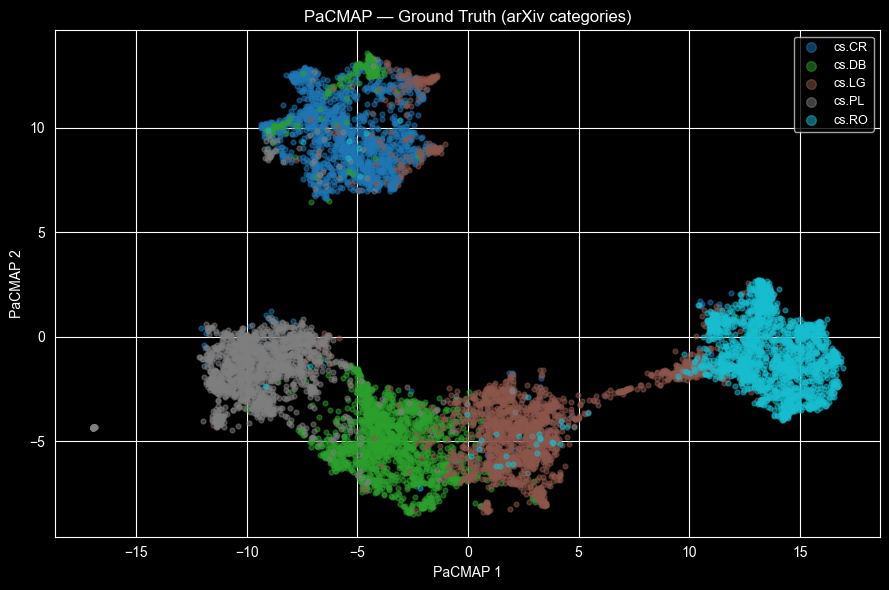

In [8]:
import pacmap
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score)
from sklearn.metrics import homogeneity_completeness_v_measure

feat_cols = [c for c in dataset.columns if c.startswith('emb_')]
X_sc      = dataset[feat_cols].values
X_cos     = X_sc

reducer = pacmap.PaCMAP(n_components=2, random_state=42)
X_pca   = reducer.fit_transform(X_sc)

le          = LabelEncoder()
true_labels = le.fit_transform(dataset['category'])
class_names = {i: c for i, c in enumerate(le.classes_)}
ext_results = {}

HIER_N     = 1000
hier_idx   = np.random.default_rng(42).choice(len(X_sc), HIER_N, replace=False)
X_hier     = X_sc[hier_idx]
X_cos_hier = X_hier
X_pca_hier = X_pca[hier_idx]

print(f"Embedding dim : {X_sc.shape[1]}  |  Samples: {len(X_sc)}")
print(f"Classes       : {list(class_names.values())}")

cmap_gt = plt.get_cmap('tab10', len(class_names))
fig, ax = plt.subplots(figsize=(9, 6))
for i, cls in class_names.items():
    mask = true_labels == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=12, alpha=0.5,
               color=cmap_gt(i), label=cls)
ax.set_title('PaCMAP — Ground Truth (arXiv categories)')
ax.set_xlabel('PaCMAP 1'); ax.set_ylabel('PaCMAP 2')
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout(); plt.show()

In [9]:
def plot_clusters(X_pca, labels, title, ax):
    unique = np.unique(labels)
    cmap   = plt.get_cmap('tab10', max(len(unique), 1))
    for i, lbl in enumerate(unique):
        mask = labels == lbl
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=8, alpha=0.4,
                   color='grey' if lbl == -1 else cmap(i))
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('PaCMAP 1'); ax.set_ylabel('PaCMAP 2')
    ax.legend(ncol=2, fontsize=7, markerscale=2)

def print_metrics(labels, X, name):
    mask = labels != -1
    if mask.sum() < 2 or len(np.unique(labels[mask])) < 2:
        print(f"{name}: insufficient clusters"); return
    sil = silhouette_score(X[mask], labels[mask], sample_size=min(3000, mask.sum()), random_state=42)
    db  = davies_bouldin_score(X[mask], labels[mask])
    ch  = calinski_harabasz_score(X[mask], labels[mask])
    print(f"{name:<50} Silhouette={sil:.4f}  DB={db:.4f}  CH={ch:.1f}")

def print_cluster_keywords(labels, idx=None, n_top=8):
    X_sub = X_tfidf[idx] if idx is not None else X_tfidf
    for lbl in sorted(np.unique(labels)):
        mask = labels == lbl
        if lbl == -1:
            print(f"  Noise   : {mask.sum():>5} docs")
            continue
        avg   = np.asarray(X_sub[mask].mean(axis=0)).ravel()
        top   = avg.argsort()[-n_top:][::-1]
        kws   = ', '.join(vocab[top])
        print(f"  C{lbl:<3}  : {mask.sum():>5} docs  |  {kws}")

def external_metrics(true_labels, pred_labels):
    mask = pred_labels != -1
    t, p = true_labels[mask], pred_labels[mask]
    if len(set(p)) < 2:
        return {"ARI": np.nan, "NMI": np.nan, "Homogeneity": np.nan, "Completeness": np.nan}
    hom, comp, _ = homogeneity_completeness_v_measure(t, p)
    return {"ARI": adjusted_rand_score(t, p),
            "NMI": normalized_mutual_info_score(t, p),
            "Homogeneity": hom, "Completeness": comp}

def collect_metrics(name, labels, X):
    mask       = labels != -1
    n_clusters = len(np.unique(labels[mask]))
    noise_pct  = (labels == -1).mean() * 100
    if mask.sum() >= 2 and n_clusters >= 2:
        sil = silhouette_score(X[mask], labels[mask], sample_size=3000, random_state=42)
        db  = davies_bouldin_score(X[mask], labels[mask])
        ch  = calinski_harabasz_score(X[mask], labels[mask])
    else:
        sil = db = ch = np.nan
    return {'Algorithm': name, 'k': n_clusters, 'Noise%': round(noise_pct, 1),
            'Silhouette↑': round(sil, 4), 'Davies-Bouldin↓': round(db, 4),
            'Calinski-Harabasz↑': round(ch, 1)}

### 3.1 Finding Optimal k

Elbow (inertia) and Silhouette score across a range of k values. Davies-Bouldin and Calinski-Harabasz confirm the choice.

Best k by silhouette : 5  (score=0.0682)
True number of classes: 5


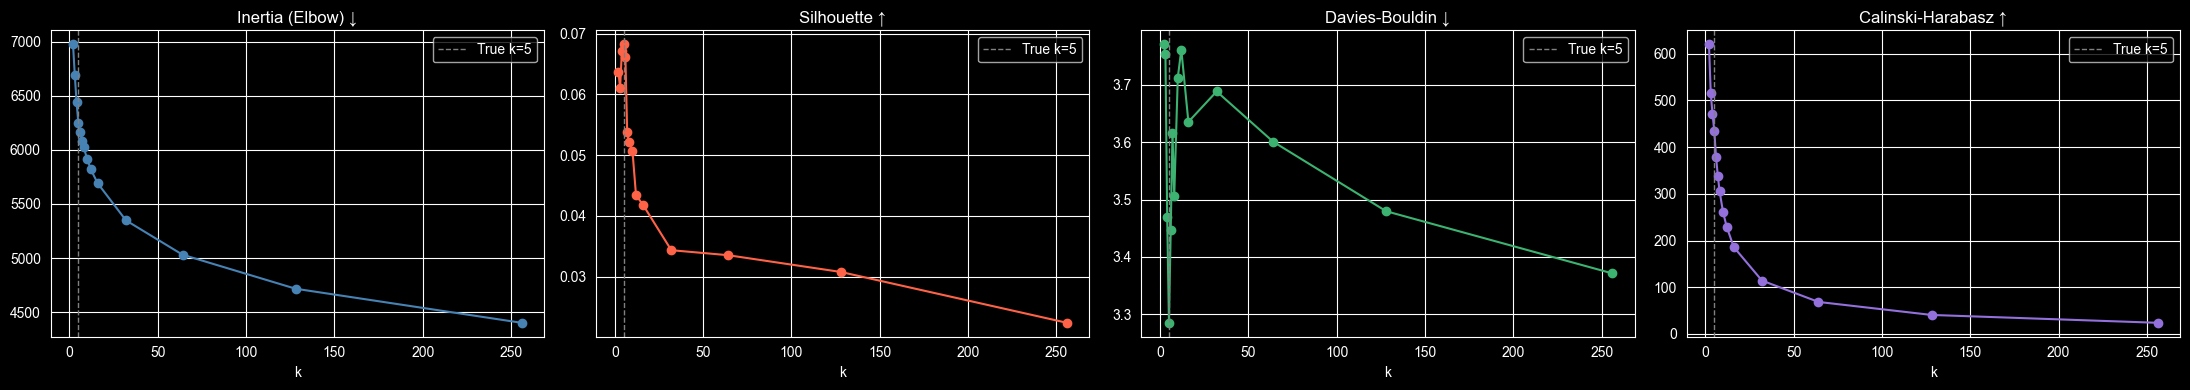

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

KS     = [2, 3, 4, 5, 6, 7, 8, 10, 12, 16, 32, 64, 128, 256]
TRUE_K = 5

inertias, sil_scores, db_scores, ch_scores = [], [], [], []

for k in KS:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_sc)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sc, lbl, sample_size=3000, random_state=42))
    db_scores.append(davies_bouldin_score(X_sc, lbl))
    ch_scores.append(calinski_harabasz_score(X_sc, lbl))

fig, axes = plt.subplots(1, 4, figsize=(22, 4))
for ax, vals, title, color in zip(
    axes,
    [inertias, sil_scores, db_scores, ch_scores],
    ['Inertia (Elbow) ↓', 'Silhouette ↑', 'Davies-Bouldin ↓', 'Calinski-Harabasz ↑'],
    ['steelblue', 'tomato', 'mediumseagreen', 'mediumpurple']
):
    ax.plot(KS, vals, marker='o', color=color)
    ax.axvline(TRUE_K, color='grey', linestyle='--', linewidth=1, label=f'True k={TRUE_K}')
    ax.set_xlabel('k'); ax.set_title(title); ax.grid(True); ax.legend()

best_k = KS[int(np.argmax(sil_scores))]
print(f"Best k by silhouette : {best_k}  (score={max(sil_scores):.4f})")
print(f"True number of classes: {TRUE_K}")
plt.tight_layout(); plt.show()

### 3.2 k-Means

/var/folders/mp/5gv0pld5539b9f_jpsxwp6nh0000gn/T/ipykernel_94891/3967313292.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(ncol=2, fontsize=7, markerscale=2)


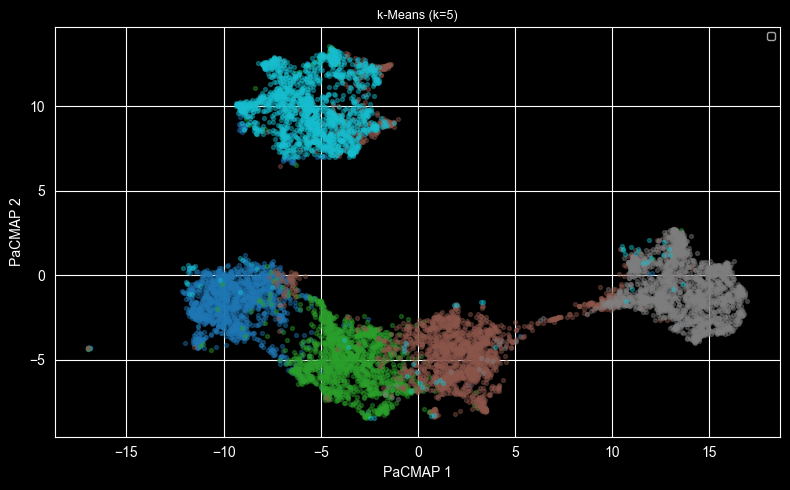

k-Means (k=5)                                      Silhouette=0.0682  DB=3.2854  CH=435.4
  C0    :  1627 docs  |  program, language, type, programming, semantics, use, code, implementation
  C1    :  1634 docs  |  query, data, database, graph, algorithm, use, base, paper
  C2    :  1976 docs  |  model, learn, data, method, network, learning, neural, propose
  C3    :  2015 docs  |  robot, environment, task, control, method, motion, model, real
  C4    :  1761 docs  |  attack, security, privacy, data, use, base, model, user


In [11]:
km_best   = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km_best.fit_predict(X_sc)

fig, ax = plt.subplots(figsize=(8, 5))
plot_clusters(X_pca, km_labels, f'k-Means (k={best_k})', ax)
plt.tight_layout(); plt.show()

print_metrics(km_labels, X_sc, f'k-Means (k={best_k})')
ext_results[f'k-Means (k={best_k})'] = external_metrics(true_labels, km_labels)
print_cluster_keywords(km_labels)

### 3.3 k-Medians

/var/folders/mp/5gv0pld5539b9f_jpsxwp6nh0000gn/T/ipykernel_94891/3967313292.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(ncol=2, fontsize=7, markerscale=2)


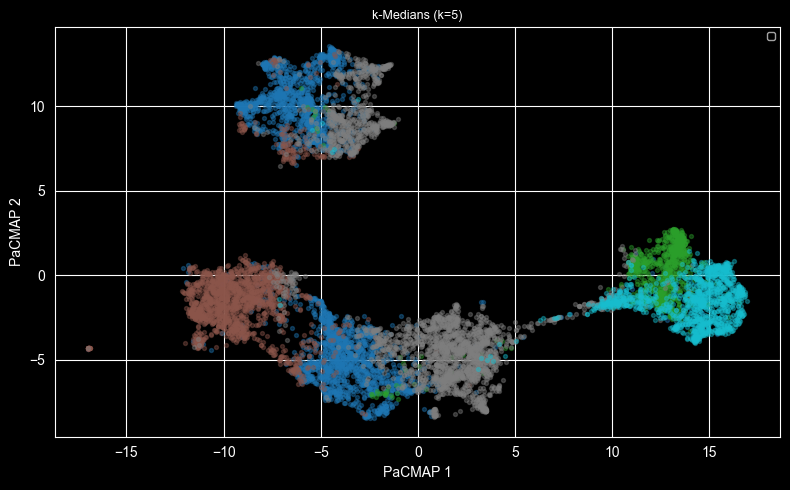

k-Medians (k=5)                                    Silhouette=0.0510  DB=4.0687  CH=371.1
  C0    :  2743 docs  |  data, query, database, use, base, paper, security, user
  C1    :   920 docs  |  robot, vehicle, environment, autonomous, trajectory, navigation, planning, method
  C2    :  1751 docs  |  program, language, type, use, semantics, programming, code, implementation
  C3    :  2383 docs  |  model, learn, data, method, network, learning, propose, neural
  C4    :  1216 docs  |  robot, task, control, policy, learn, robotic, human, manipulation


In [12]:
def k_medians(X, k, max_iter=100, random_state=42):
    rng     = np.random.default_rng(random_state)
    medians = X[rng.choice(len(X), size=k, replace=False)].copy()
    for _ in range(max_iter):
        labels = np.empty(len(X), dtype=int)
        for start in range(0, len(X), 1000):
            end = min(start + 1000, len(X))
            dists = np.abs(X[start:end, None, :] - medians[None, :, :]).sum(axis=2)
            labels[start:end] = dists.argmin(axis=1)
        new_medians = np.array([np.median(X[labels == j], axis=0)
                                if (labels == j).any() else medians[j]
                                for j in range(k)])
        if np.allclose(medians, new_medians): break
        medians = new_medians
    return labels, medians

kmed_labels, _ = k_medians(X_sc, best_k)

fig, ax = plt.subplots(figsize=(8, 5))
plot_clusters(X_pca, kmed_labels, f'k-Medians (k={best_k})', ax)
plt.tight_layout(); plt.show()

print_metrics(kmed_labels, X_sc, f'k-Medians (k={best_k})')
ext_results[f'k-Medians (k={best_k})'] = external_metrics(true_labels, kmed_labels)
print_cluster_keywords(kmed_labels)

### 3.4 Hierarchical Clustering (Agglomerative)

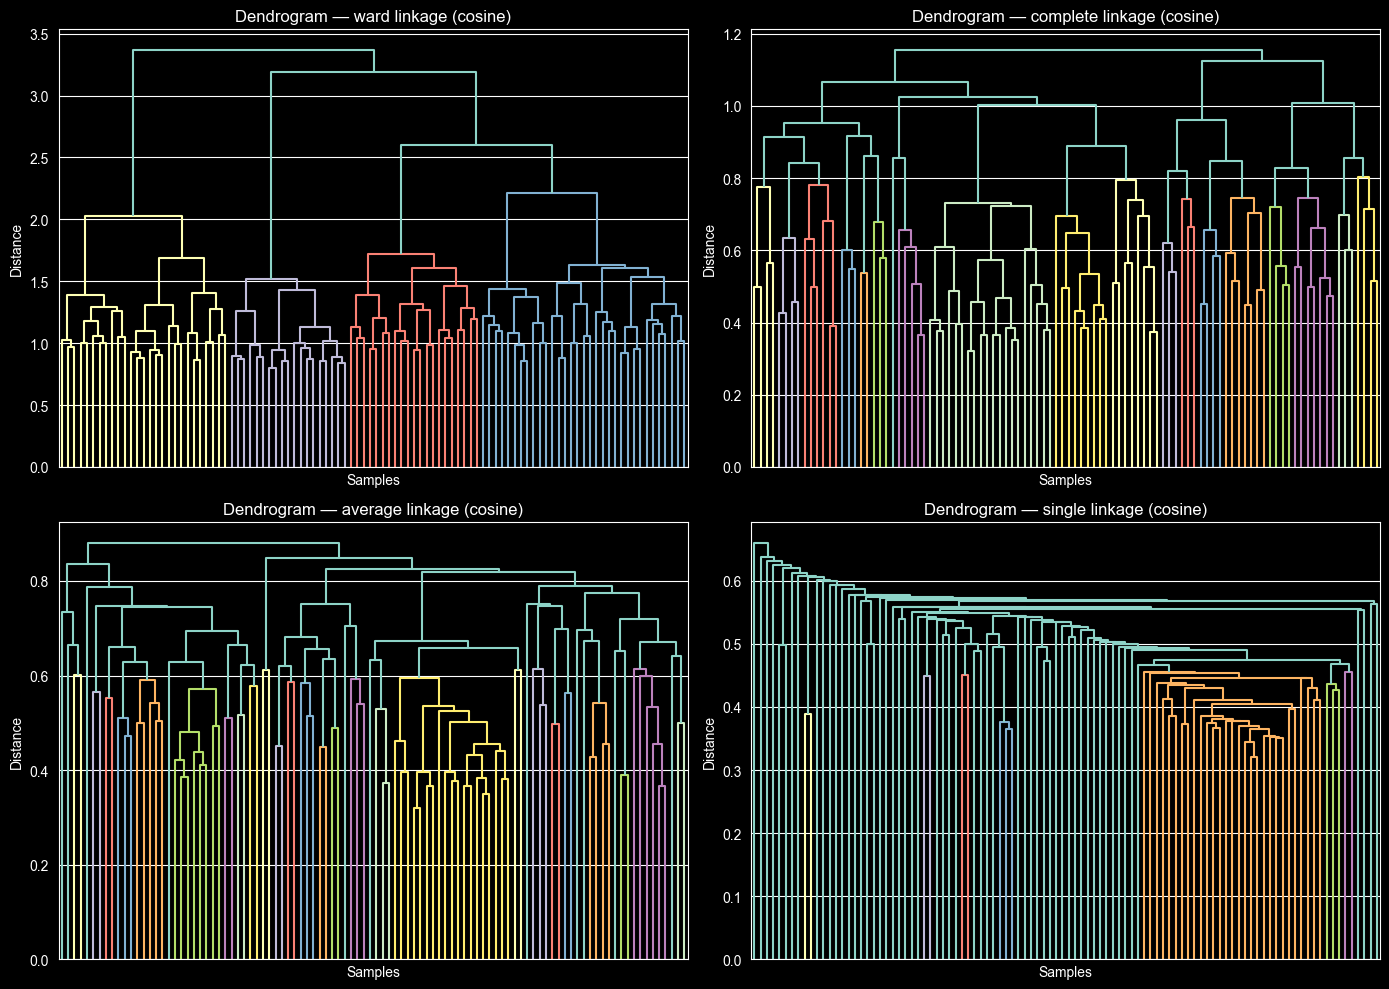

In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

dend_idx  = np.random.default_rng(0).choice(len(X_sc), 100, replace=False)
X_dend    = X_cos[dend_idx]
dist_cond = pdist(X_dend, metric='cosine')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, method in zip(axes.flatten(), ['ward', 'complete', 'average', 'single']):
    Z = linkage(dist_cond if method != 'ward' else X_dend, method=method)
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=0.7 * max(Z[:, 2]))
    ax.set_title(f'Dendrogram — {method} linkage (cosine)')
    ax.set_xlabel('Samples'); ax.set_ylabel('Distance')
plt.tight_layout(); plt.show()

Hierarchical ward (k=5)                            Silhouette=0.0548  DB=3.4870  CH=43.6
  ward cluster sizes: [272, 226, 198, 191, 113]
Hierarchical complete (k=5)                        Silhouette=0.0522  DB=3.6234  CH=43.4
  complete cluster sizes: [255, 246, 177, 172, 150]
Hierarchical average (k=5)                         Silhouette=0.0419  DB=2.6844  CH=18.9
  average cluster sizes: [543, 446, 7, 3, 1]
Hierarchical single (k=5)                          Silhouette=0.0026  DB=0.9013  CH=1.2
  single cluster sizes: [996, 1, 1, 1, 1]


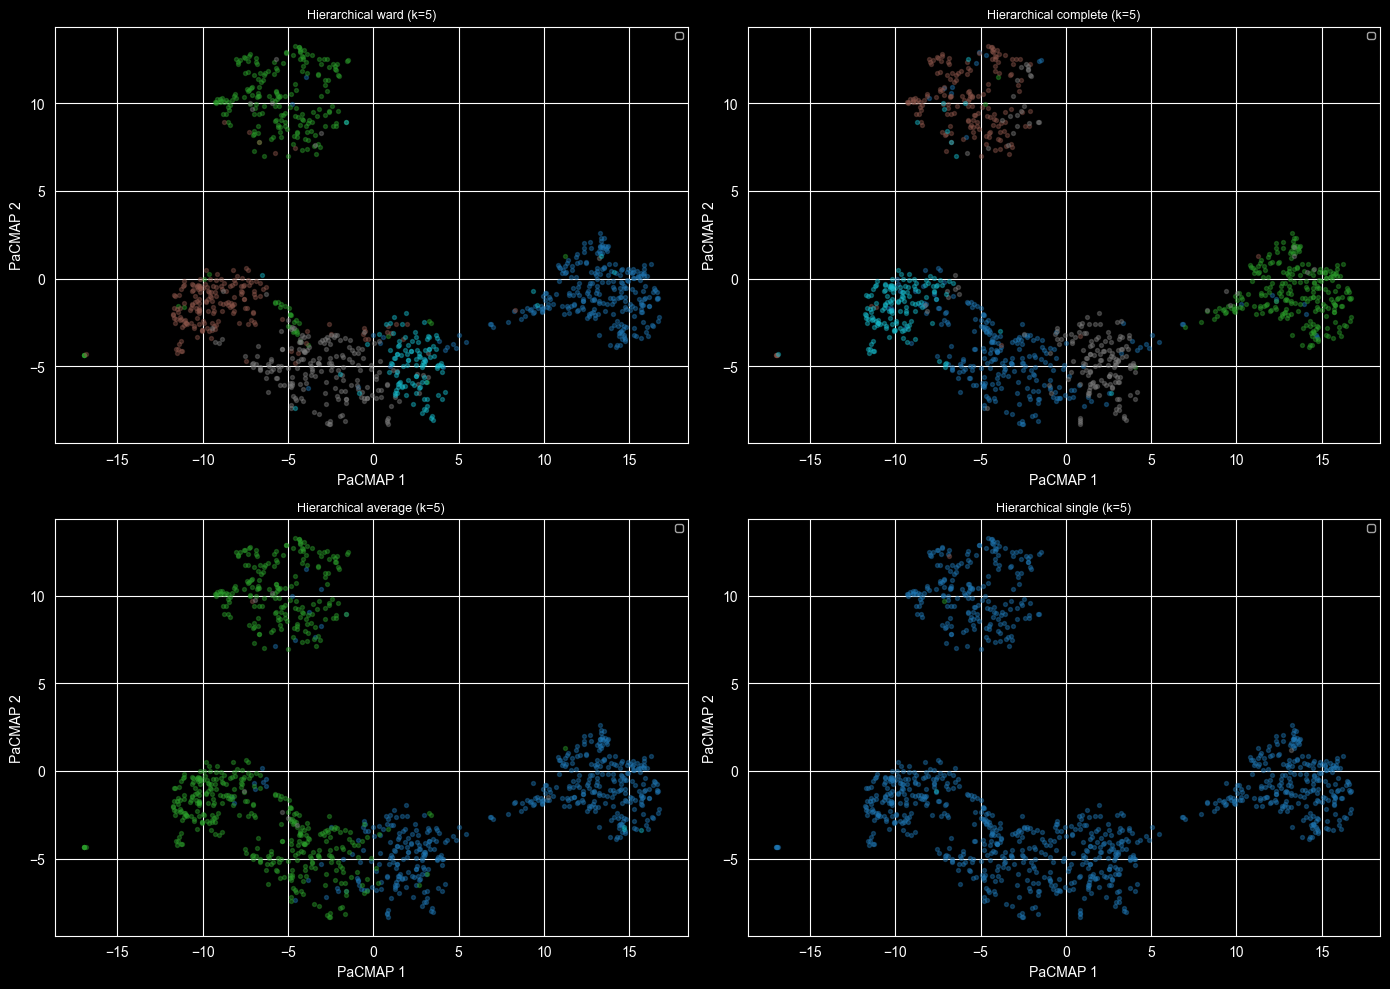


── ward linkage ──
  C0    :   272 docs  |  robot, task, method, learn, model, use, policy, environment
  C1    :   226 docs  |  privacy, attack, data, security, use, user, model, base
  C2    :   191 docs  |  program, language, type, use, semantics, programming, code, present
  C3    :   198 docs  |  data, query, graph, database, use, propose, base, algorithm
  C4    :   113 docs  |  model, neural, network, learn, data, propose, method, learning

── complete linkage ──
  C0    :   255 docs  |  data, query, database, use, algorithm, propose, base, time
  C1    :   246 docs  |  robot, task, method, policy, learn, environment, use, robotic
  C2    :   172 docs  |  privacy, attack, security, data, use, private, base, user
  C3    :   177 docs  |  model, data, neural, network, learn, method, propose, task
  C4    :   150 docs  |  program, language, type, use, semantics, compiler, programming, implement

── average linkage ──
  C0    :   446 docs  |  model, robot, method, task, learn, prop

In [14]:
from sklearn.cluster import AgglomerativeClustering
import warnings
warnings.filterwarnings('ignore')

linkage_methods = ['ward', 'complete', 'average', 'single']
hier_labels = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, method in zip(axes.flatten(), linkage_methods):
    if method == 'ward':
        hc  = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
        lbl = hc.fit_predict(X_cos_hier)
    else:
        hc  = AgglomerativeClustering(n_clusters=best_k, linkage=method,
                                      metric='cosine')
        lbl = hc.fit_predict(X_cos_hier)
    hier_labels[method] = lbl
    plot_clusters(X_pca_hier, lbl, f'Hierarchical {method} (k={best_k})', ax)
    print_metrics(lbl, X_cos_hier, f'Hierarchical {method} (k={best_k})')
    ext_results[f'Hierarchical {method}'] = external_metrics(true_labels[hier_idx], lbl)

    sizes = sorted(np.bincount(lbl), reverse=True)
    print(f"  {method} cluster sizes: {sizes}")

plt.tight_layout(); plt.show()

for method in linkage_methods:
    print(f"\n── {method} linkage ──")
    print_cluster_keywords(hier_labels[method], idx=hier_idx)

*Note*: Single linkage merges the two clusters whose *closest* pair of points is smallest. In a continuous embedding space without sharp density gaps, there is almost always a short bridge between any two groups, so the algorithm chains them into one giant cluster and leaves the remaining k−1 cuts as singletons.

### 3.5 Nearest Neighbour Clustering

Threshold (30th pct of 5-NN dist on subsample): 0.8607

Iter 1: threshold=0.8607  clusters=748  singletons=641 (64.1%)
Iter 2: threshold=1.0328  clusters=129  singletons=70 (7.0%)

Final: clusters=129  threshold=1.0328


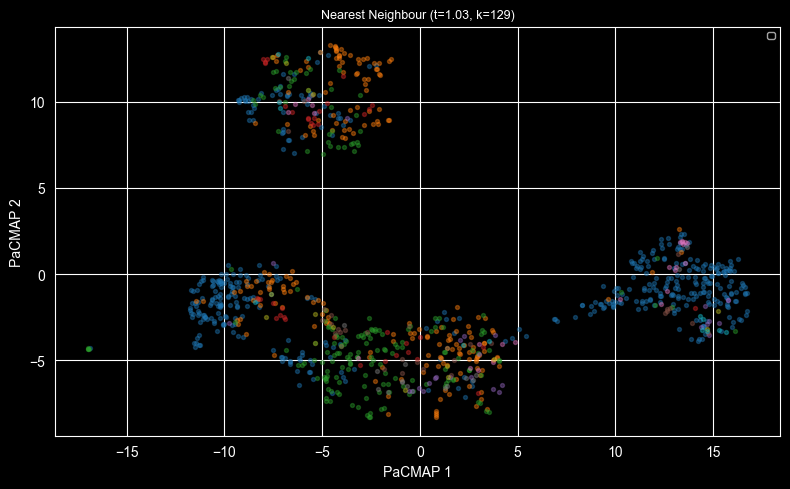

Nearest Neighbour (t=1.03)                         Silhouette=-0.0222  DB=1.6870  CH=3.6
  C0    :    84 docs  |  program, type, language, use, semantics, implementation, implement, provide
  C1    :    68 docs  |  program, language, semantics, use, formal, specification, prove, type
  C2    :   188 docs  |  robot, task, learn, model, object, real, method, policy
  C3    :     2 docs  |  spectrum, fund, blockchain, trading, user, edge, traceability, satellite
  C4    :     3 docs  |  xml, fragmentation, web, data, exchange, warehouse, standard, fragment
  C5    :     6 docs  |  model, moe, decoding, mcmc, large, reward, token, speedup
  C6    :     7 docs  |  blockchain, miner, mining, incentive, protocol, block, proof, game
  C7    :    22 docs  |  user, blockchain, proof, private, attack, privacy, data, service
  C8    :    24 docs  |  robot, environment, navigation, agent, planning, collision, path, motion
  C9    :    15 docs  |  query, datalog, set, quality, answer, data, algorith

In [15]:
from sklearn.neighbors import BallTree, NearestNeighbors

def nn_clustering(X, threshold, max_singleton_ratio=0.3, threshold_scale=1.2, max_iters=5):
    n = len(X)
    k = min(50, n)
    tree = BallTree(X)
    all_dists, all_idxs = tree.query(X, k=k)

    best_labels    = None
    best_threshold = threshold
    best_singletons = n

    for iteration in range(max_iters):
        labels = np.empty(n, dtype=int)
        labels[0] = 0
        next_id = 1

        for i in range(1, n):
            nn_dist = nn_label = None
            for dist, idx in zip(all_dists[i], all_idxs[i]):
                if idx < i:
                    nn_dist, nn_label = dist, labels[idx]
                    break
            if nn_dist is None:
                dists = np.linalg.norm(X[:i] - X[i], axis=1)
                j = int(np.argmin(dists))
                nn_dist, nn_label = dists[j], labels[j]

            if nn_dist <= threshold:
                labels[i] = nn_label
            else:
                labels[i] = next_id
                next_id += 1

        counts       = np.bincount(labels)
        n_singletons = int(np.sum(counts == 1))
        n_clusters   = len(np.unique(labels))

        print(f"Iter {iteration + 1}: threshold={threshold:.4f}  "
              f"clusters={n_clusters}  singletons={n_singletons} ({n_singletons/n:.1%})")

        if n_clusters > 1 and n_singletons < best_singletons:
            best_singletons = n_singletons
            best_labels     = labels.copy()
            best_threshold  = threshold

        if n_singletons / n <= max_singleton_ratio:
            break

        if n_clusters == 1:
            print("  → threshold too large, collapsed to 1 cluster — reverting to best result")
            break

        threshold *= threshold_scale

    if best_labels is None:
        best_labels    = labels
        best_threshold = threshold

    unique = np.unique(best_labels)
    remap  = {u: k for k, u in enumerate(unique)}
    return np.array([remap[l] for l in best_labels]), best_threshold


d_hier, _ = NearestNeighbors(n_neighbors=5).fit(X_hier).kneighbors(X_hier)
threshold  = float(np.percentile(d_hier[:, -1], 10))
print(f"Threshold (30th pct of 5-NN dist on subsample): {threshold:.4f}\n")

nn_labels, threshold = nn_clustering(X_hier, threshold)
n_nn = len(np.unique(nn_labels))
print(f"\nFinal: clusters={n_nn}  threshold={threshold:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
plot_clusters(X_pca_hier, nn_labels,
              f'Nearest Neighbour (t={threshold:.2f}, k={n_nn})', ax)
plt.tight_layout(); plt.show()

print_metrics(nn_labels, X_hier, f'Nearest Neighbour (t={threshold:.2f})')
ext_results['Nearest Neighbour'] = external_metrics(true_labels[hier_idx], nn_labels)
print_cluster_keywords(nn_labels, idx=hier_idx)

### 3.6 DBSCAN

Distance percentiles: 5%=0.731 10%=0.760  50%=0.861  90%=0.965


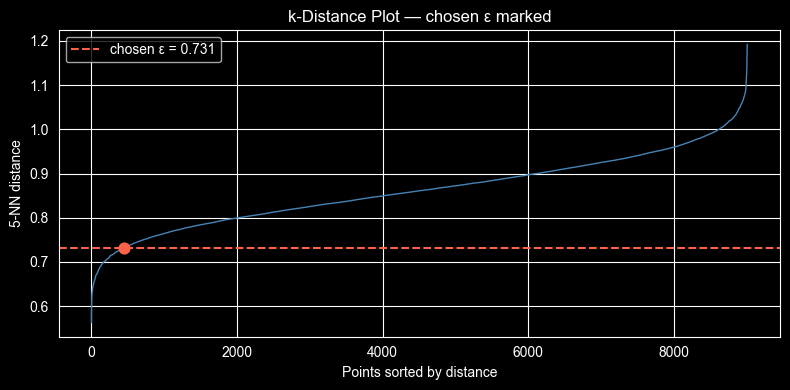

eps=0.731, clusters=54, noise=88.9%


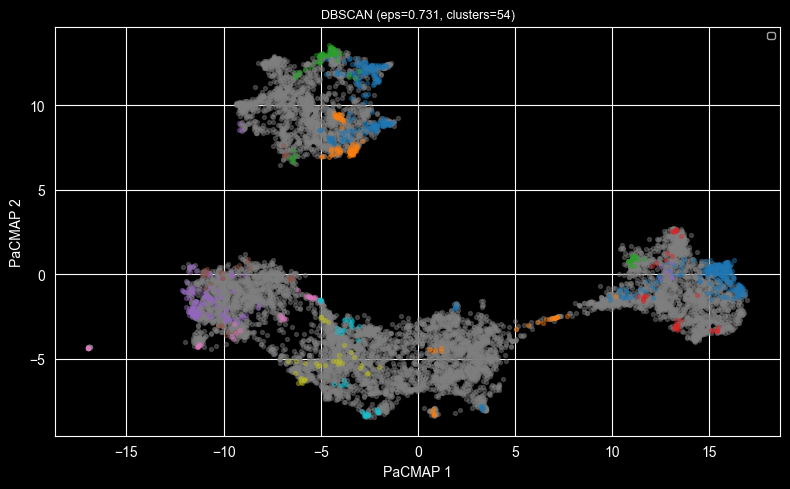

DBSCAN (eps=0.731)                                 Silhouette=0.0963  DB=1.7966  CH=19.0
  Noise   :  8010 docs
  C0    :     5 docs  |  graph, node, contrastive, gnns, representation, learn, positive, sample
  C1    :   211 docs  |  manipulation, robot, task, policy, demonstration, learn, action, robotic
  C2    :    99 docs  |  privacy, fl, client, federate, model, data, federated, private
  C3    :    92 docs  |  adversarial, attack, malware, backdoor, detection, model, defense, example
  C4    :     5 docs  |  quantization, bit, integer, float, deep, point, loss, network
  C5    :    14 docs  |  regret, bandit, bound, arm, ucb, algorithm, learner, upper
  C6    :     5 docs  |  fairness, group, metric, intervention, bias, mitigation, scaling, machine
  C7    :     6 docs  |  explanation, xai, explainable, decision, model, machine, method, learn
  C8    :    47 docs  |  llm, attack, jailbreak, prompt, defense, vulnerability, harmful, model
  C9    :    16 docs  |  intrusion, iot, de

In [16]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

min_samples = 5
nbrs    = NearestNeighbors(n_neighbors=min_samples).fit(X_cos)
distances, _ = nbrs.kneighbors(X_cos)
k_dists = np.sort(distances[:, -1])

print(f"Distance percentiles: 5%={np.percentile(k_dists,5):.3f} "
      f"10%={np.percentile(k_dists,10):.3f}  "
      f"50%={np.percentile(k_dists,50):.3f}  90%={np.percentile(k_dists,90):.3f}")
best_eps = np.percentile(k_dists, 5)

plt.figure(figsize=(8, 4))
plt.plot(k_dists, color='steelblue', linewidth=1)
plt.axhline(best_eps, color='tomato', linestyle='--', linewidth=1.5,
            label=f'chosen ε = {best_eps:.3f}')
knee_idx = int(np.argmin(np.abs(k_dists - best_eps)))
plt.scatter([knee_idx], [k_dists[knee_idx]], color='tomato', zorder=5, s=60)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_samples}-NN distance')
plt.title('k-Distance Plot — chosen ε marked')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

db_best       = DBSCAN(eps=best_eps, min_samples=5)
db_labels     = db_best.fit_predict(X_cos)
n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f"eps={best_eps:.3f}, clusters={n_db_clusters}, noise={(db_labels==-1).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(8, 5))
plot_clusters(X_pca, db_labels,
              f'DBSCAN (eps={best_eps:.3f}, clusters={n_db_clusters})', ax)
plt.tight_layout(); plt.show()

print_metrics(db_labels, X_cos, f'DBSCAN (eps={best_eps:.3f})')
ext_results['DBSCAN'] = external_metrics(true_labels, db_labels)
print_cluster_keywords(db_labels)

## 4. Comparative Analysis of Clustering Algorithms

In [21]:
rows = [
    collect_metrics(f'k-Means (k={best_k})',            km_labels,               X_sc),
    collect_metrics(f'k-Medians (k={best_k})',           kmed_labels,             X_sc),
    collect_metrics(f'Hier. ward',          hier_labels['ward'],     X_cos_hier),
    collect_metrics(f'Hier. complete',      hier_labels['complete'], X_cos_hier),
    collect_metrics(f'Hier. average',       hier_labels['average'],  X_cos_hier),
    collect_metrics(f'Hier. single',       hier_labels['single'],  X_cos_hier),
    collect_metrics(f'Nearest Neighbour',                nn_labels,               X_cos_hier),
    collect_metrics(f'DBSCAN (eps={best_eps:.3f})',      db_labels,               X_sc),
]
summary_df = pd.DataFrame(rows).set_index('Algorithm')
print("Internal metrics:")
display(summary_df)

Internal metrics:


,k,Noise%,Silhouette↑,Davies-Bouldin↓,Calinski-Harabasz↑
Algorithm,,,,,
k-Means (k=5),5,0.0,0.0682,3.2854,435.4
k-Medians (k=5),5,0.0,0.0510,4.0687,371.1
Hier. ward,5,0.0,0.0548,3.4870,43.6
Hier. complete,5,0.0,0.0522,3.6234,43.4
Hier. average,5,0.0,0.0419,2.6844,18.9
Hier. single,5,0.0,0.0026,0.9013,1.2
Nearest Neighbour,129,0.0,-0.0222,1.6870,3.6
DBSCAN (eps=0.731),54,88.9,0.0963,1.7966,19.0


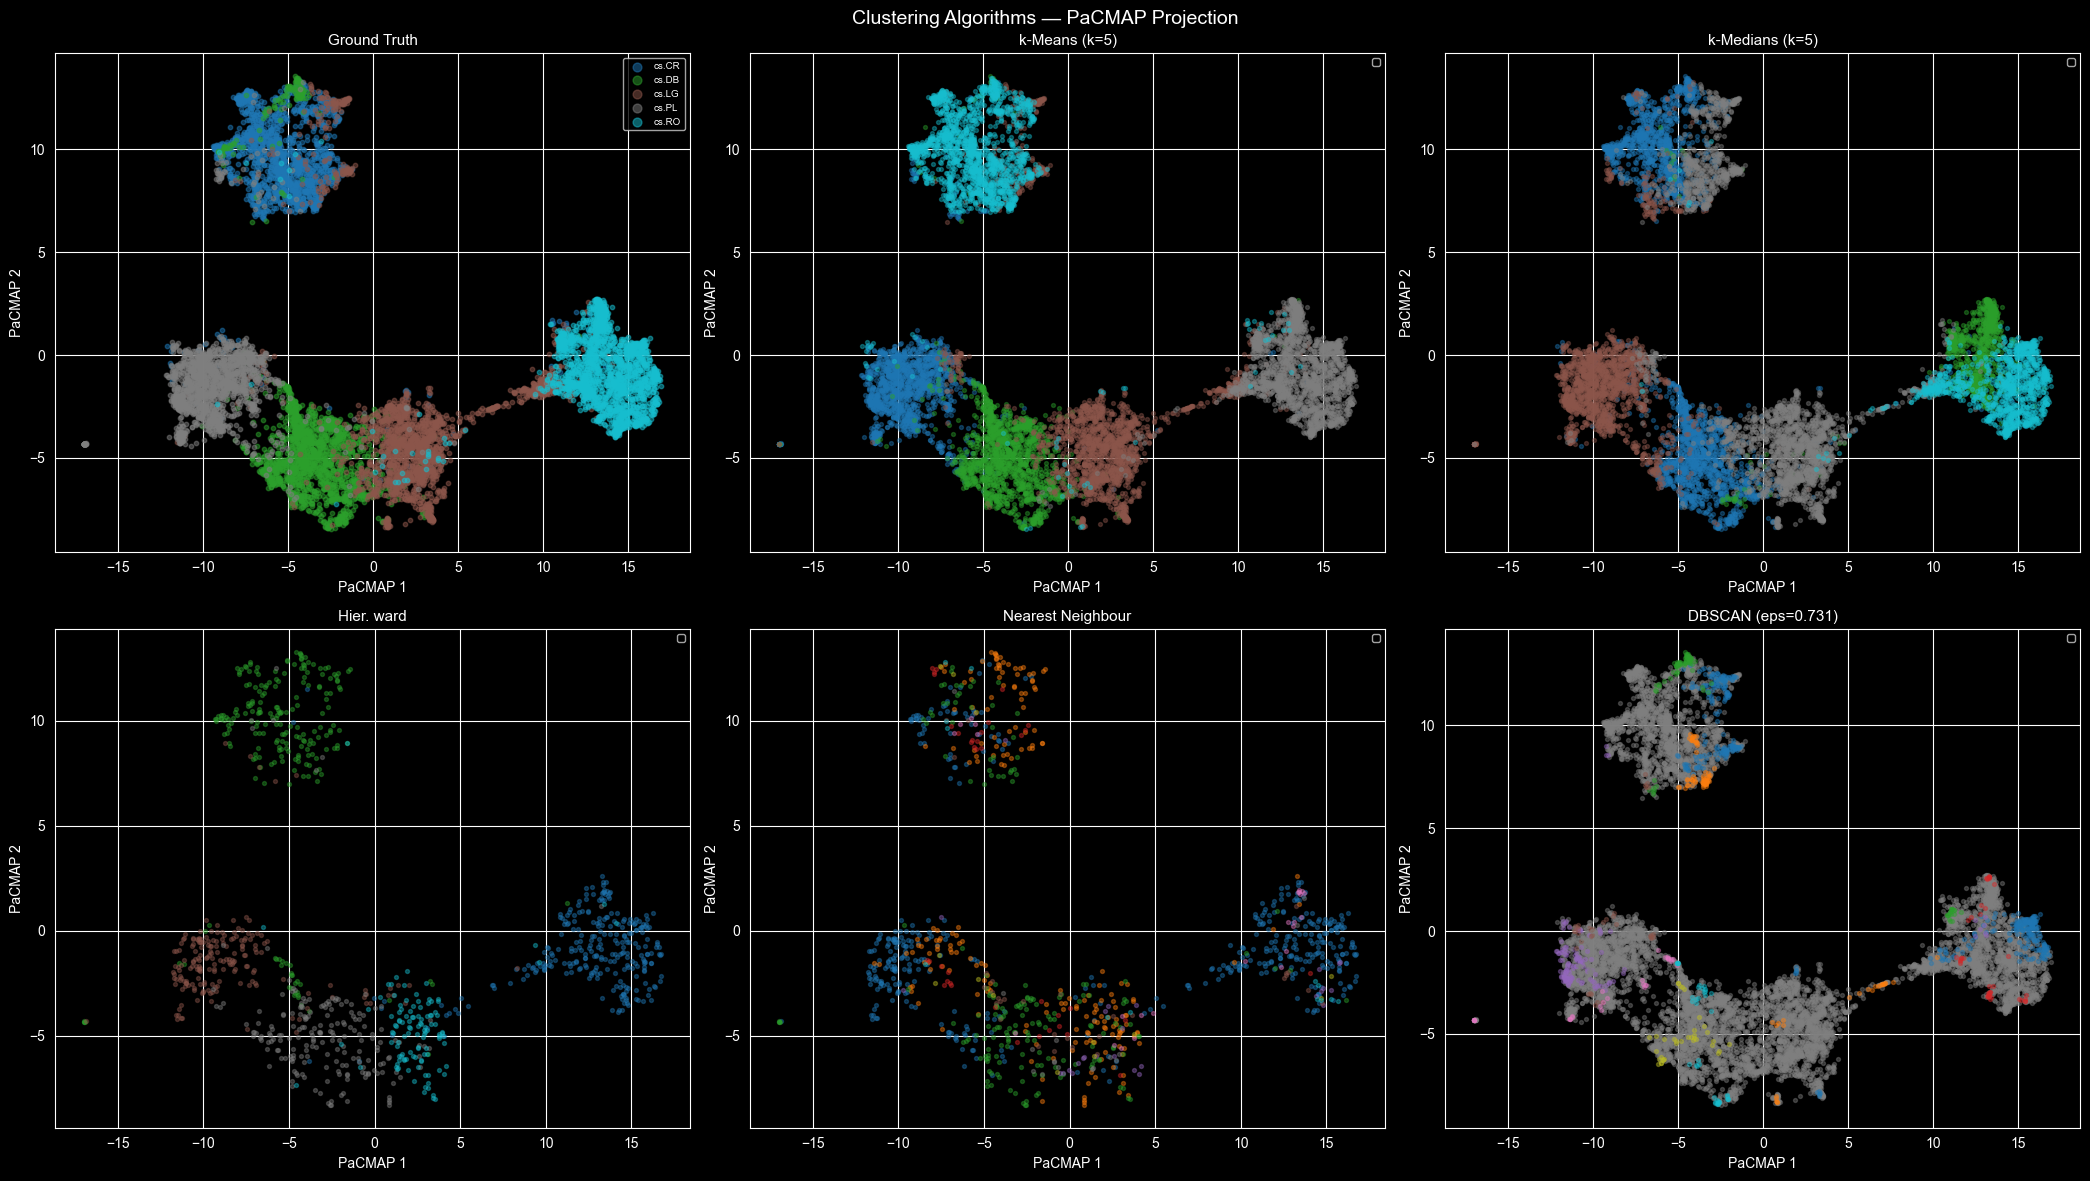

In [22]:
all_label_sets = [
    ('Ground Truth',                    X_pca,      true_labels),
    (f'k-Means (k={best_k})',           X_pca,      km_labels),
    (f'k-Medians (k={best_k})',         X_pca,      kmed_labels),
    (f'Hier. ward',        X_pca_hier, hier_labels['ward']),
    (f'Nearest Neighbour',              X_pca_hier, nn_labels),
    (f'DBSCAN (eps={best_eps:.3f})',    X_pca,      db_labels),
]

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
axes = axes.flatten()

for ax, (name, emb, lbl) in zip(axes, all_label_sets):
    if name == 'Ground Truth':
        cmap_gt = plt.get_cmap('tab10', len(class_names))
        for i, cls in class_names.items():
            mask = true_labels == i
            ax.scatter(emb[mask, 0], emb[mask, 1], s=10, alpha=0.5,
                       color=cmap_gt(i), label=cls)
        ax.legend(fontsize=7, markerscale=2)
    else:
        plot_clusters(emb, lbl, name, ax)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('PaCMAP 1'); ax.set_ylabel('PaCMAP 2')

plt.suptitle('Clustering Algorithms — PaCMAP Projection', fontsize=14)
plt.tight_layout()
plt.show()

External metrics vs Ground Truth:


,ARI,NMI,Homogeneity,Completeness
k-Means (k=5),0.7669,0.7351,0.7345,0.7358
k-Medians (k=5),0.4891,0.5608,0.5481,0.5740
Hierarchical ward,0.5914,0.5966,0.5905,0.6028
Hierarchical complete,0.6007,0.5968,0.5932,0.6004
Hierarchical average,0.2879,0.3868,0.2838,0.6071
Hierarchical single,0.0001,0.0080,0.0041,0.2072
Nearest Neighbour,0.2506,0.4425,0.7049,0.3225
DBSCAN,0.3986,0.5667,0.8446,0.4264


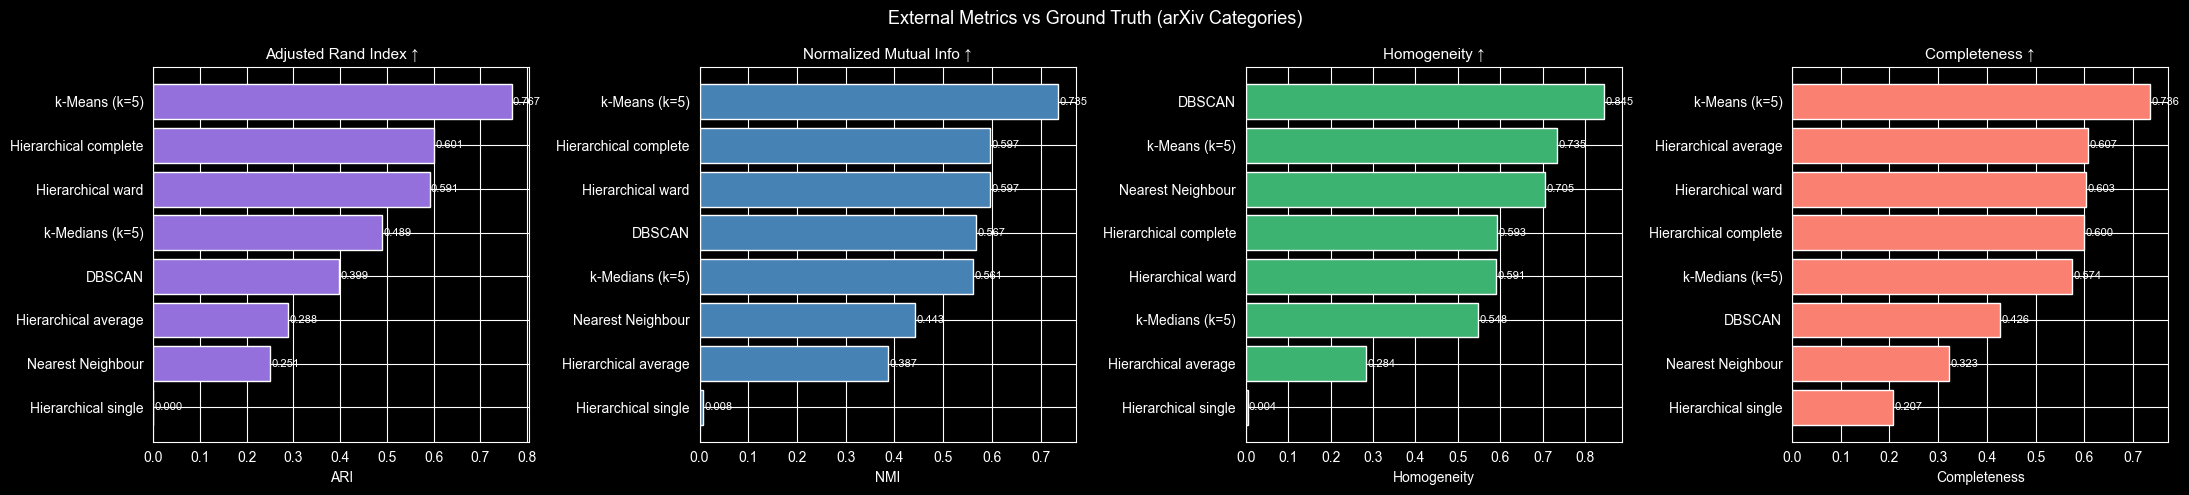

In [19]:
ext_df = pd.DataFrame(ext_results).T.round(4)
print("External metrics vs Ground Truth:")
display(ext_df)

ext_cfg = [
    ('ARI',          'Adjusted Rand Index ↑',    'mediumpurple'),
    ('NMI',          'Normalized Mutual Info ↑',  'steelblue'),
    ('Homogeneity',  'Homogeneity ↑',             'mediumseagreen'),
    ('Completeness', 'Completeness ↑',            'salmon'),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (metric, title, color) in zip(axes, ext_cfg):
    vals = ext_df[metric].dropna().sort_values()
    bars = ax.barh(vals.index, vals.values, color=color, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(metric)
    ax.axvline(0, color='grey', linewidth=0.8)
    for bar, val in zip(bars, vals.values):
        ax.text(max(bar.get_width(), 0) + 0.003,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('External Metrics vs Ground Truth (arXiv Categories)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Conclusions — Clustering

### Why the categories are hard to separate

- **cs.LG ↔ cs.RO**: Robotics relies heavily on ML for control and perception — many cs.RO abstracts could plausibly be cs.LG.
- **cs.LG ↔ cs.DB**: Learned indexes and ML-for-query-optimisation papers appear in both venues.
- **Academic boilerplate**: "we propose", "state-of-the-art", "we present a novel" appear in every category with high TF-IDF weight, pulling all embeddings toward a common centroid.
- **Within-category diversity**: cs.CR alone spans cryptographic proofs, side-channel attacks, and network security — internally diverse enough to split into several sub-clusters.

### Algorithm comparison

| Method | k | Silhouette↑ | DB↓     | ARI↑ | NMI↑ | Homogeneity↑ | Completeness↑ |
|---|---|-------------|---------|---|---|---|---|
| k-Means | 5 | 0.068       | 3.29    | **0.767** | **0.735** | 0.735 | 0.736 |
| k-Medians | 5 | 0.051       | 4.07    | 0.489 | 0.561 | 0.548 | 0.574 |
| Hier. ward | 5 | 0.055       | 3.49    | 0.591 | 0.597 | 0.591 | 0.603 |
| Hier. complete | 5 | 0.052       | 3.62    | 0.601 | 0.597 | 0.593 | 0.600 |
| Hier. average | 5 | 0.042       | 2.68    | 0.288 | 0.387 | 0.284 | 0.607 |
| Hier. single | 5 | 0.003       | **0.9** | ~0 | ~0 | 0.004 | 0.207 |
| **Nearest Neighbour** | **129** | −0.022      | 1.69    | 0.251 | 0.443 | **0.705** | 0.323 |
| DBSCAN | 54 | **0.096**   | 1.80    | 0.399 | 0.567 | **0.845** | 0.426 |

---

### Why single linkage and NN collapsed to 1 cluster — and the fix

Both algorithms share the same root cause: **no density gaps in the embedding space**.

**Single linkage** chains clusters through the nearest bridge point. Because sentence embeddings form a continuous manifold without clear voids, every group is reachable from every other via a short chain. Forcing `n_clusters=5` places 4 cuts at the very top of the dendrogram, each separating a single outlier, leaving one cluster with ~99% of the data. This is inherent to the algorithm — not fixable by parameter tuning on this data.

**Nearest Neighbour** originally collapsed to 1 cluster because threshold_scale=1.5 was too much of a step. Reducing the multiplier to `1.2` gave finer control.

The transition from "too fragmented" to "fully merged" is **sharp** in this embedding space — there is a narrow threshold band where a reasonable number of clusters exists. A step of ×1.5 skips over it entirely; ×1.2 lands inside it.


**Overall**: partition-based methods (k-Means, k-Medians) work best here because the embedding space is approximately hyperspherical with roughly equal-size groups. Nearest Neighbour and DBSCAN both achieve high homogeneity but over-split — they discover genuine sub-topic clusters rather than the coarse 5-category partition.